In [109]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

"""
PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)"""


PKLs = []
PKL_titles = []
DIR = "./output_low_memory_10000/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        if loaded['config']['prefix']=='vanish_05':
            PKLs.append(loaded)
            PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [110]:
my_dims = np.concatenate([np.arange(1, 11, 1), [20, 50]])
my_dims = np.concatenate([np.arange(1, 11, 1), [20]])
my_dims = np.array([50, 100])
my_dims = np.array([1, 2, 3, 5, 10, 15, 30, 50, 75, 100])

idx_per_dim = {}
for dim in my_dims:
    idx_per_dim[dim] = [idx for idx in range(n) if PKLs[idx]['config']['dim'] == dim]
temperatures = {}
parameters = {}
critical_temperatures = []
for i, dim in enumerate(my_dims):
    temperatures[dim] = np.array([PKLs[idx]['res'][6] for idx in idx_per_dim[dim]]) 
    parameters[dim] = np.array([PKLs[idx]['res'][3].squeeze(axis=-1) for idx in idx_per_dim[dim]])

In [111]:
def last_zero(x):
    return np.where(np.cumsum(x)==0.)[0][-1] if len(np.where(np.cumsum(x)==0.)[0]) else None

In [112]:
critical_temperatures = np.zeros(shape=(len(my_dims), len(parameters[50])))
for idxdim, dim in enumerate(parameters.keys()):
    number_of_runs = len(parameters[dim])
    if number_of_runs:
        critical_temperatures[idxdim] = np.array([temperatures[dim][r,0][last_zero(parameters[dim][r,0])] for r in range(number_of_runs)])

In [113]:
idx_per_dim

{1: [19, 32, 50, 57, 65, 72, 76, 79, 96, 99],
 2: [36, 52, 56, 59, 69, 74, 81, 88, 89, 94],
 3: [7, 8, 20, 21, 44, 49, 61, 63, 75, 86],
 5: [6, 11, 29, 30, 34, 55, 62, 78, 92, 93],
 10: [10, 15, 25, 28, 38, 45, 68, 71, 80, 87],
 15: [1, 2, 3, 12, 18, 27, 31, 35, 90, 91],
 30: [5, 13, 33, 37, 43, 53, 60, 70, 84, 95],
 50: [0, 9, 22, 24, 26, 41, 46, 51, 66, 97],
 75: [4, 16, 17, 39, 42, 67, 77, 83, 85, 98],
 100: [14, 23, 40, 47, 48, 54, 58, 64, 73, 82]}

In [114]:
PKLs[0]['res'][8]

Array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan]], dtype=float32)

In [118]:
for idx in idx_per_dim[50]:
    if np.any(np.isnan(PKLs[idx]['res'][5])):
        print(idx)

0
9
22
24
26
41
46
51
66
97


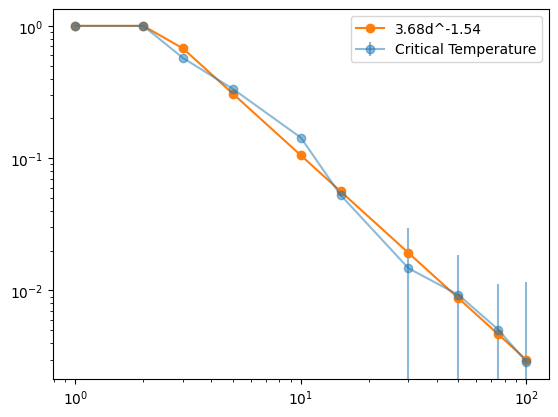

In [98]:
mean_critical_temperatures = critical_temperatures.mean(axis=-1)
log_mean_critical_temperatures = np.log(mean_critical_temperatures)

mask = log_mean_critical_temperatures < 0
filtered_log_temperatures = log_mean_critical_temperatures[mask]
filtered_dims = my_dims[mask]
filtered_log_dims = np.log(filtered_dims)
#performing linear regression
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_log_dims, filtered_log_temperatures)
regression_line = np.exp(intercept) * filtered_dims**slope
filled_regression_line = np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

plt.errorbar(my_dims, mean_critical_temperatures, yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.loglog(my_dims, filled_regression_line, marker='o', label=rf'{str(np.exp(intercept))[:4]}d^{str(slope)[:5]}')
plt.legend()

In [87]:
np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

array([1.        , 1.        , 0.67478351, 0.30641758, 0.104977  ,
       0.0560994 , 0.01921935, 0.00872746, 0.00466393, 0.00298998])

In [78]:
std_err

0.056250914807237776

In [11]:
to_remove_dims = [100]
for d in to_remove_dims:
    for idx in idx_per_dim[d]:
        os.remove(DIR+PKL_titles[idx])

        

In [6]:
critical_temperatures

array([], shape=(9, 0), dtype=float64)

In [14]:
for i in range(n):
    if "vanish" in PKLs[i]['config']['prefix']:
        os.remove(DIR+PKL_titles[i])